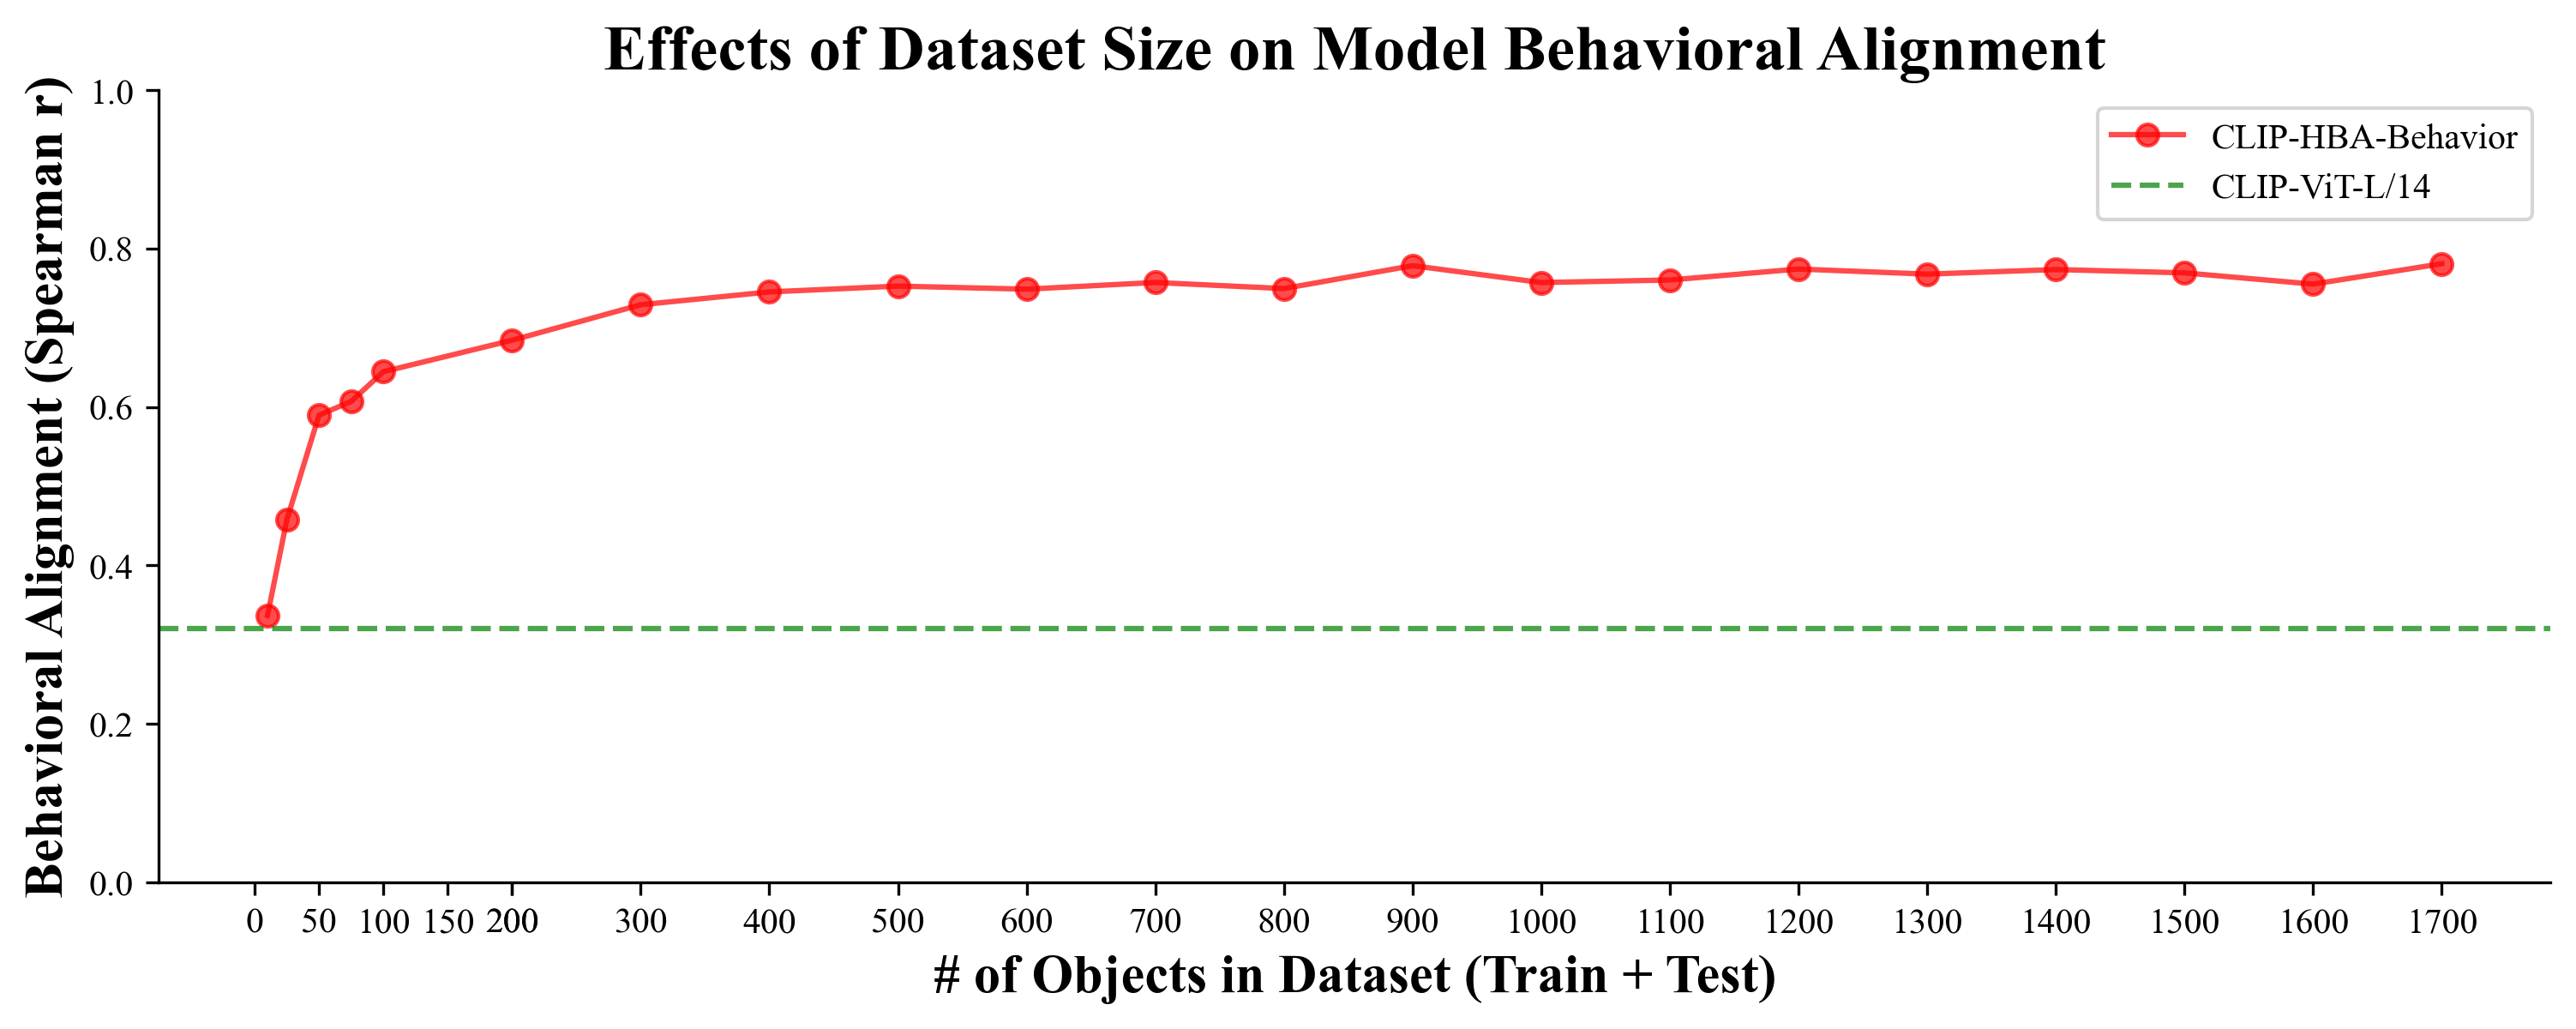

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(figsize=(12, 4), dpi=300)  # Set resolution
fig.patch.set_facecolor('none')  # Remove figure background
ax.set_facecolor('none')  # Remove axes background

baseline_y = 0.31980


path = './cliphba_behavioral_sizes.csv'

df = pd.read_csv(path)

plt.plot(df['train_size'], df['spearmanr'], marker='o', color='r', label='CLIP-HBA-Behavior', alpha = 0.7)
plt.axhline(y=baseline_y, color='g', linestyle='--', label='CLIP-ViT-L/14', alpha = 0.7)
plt.legend()
plt.ylim(0, 1)
plt.xlabel('# of Objects in Dataset (Train + Test)', fontsize=15, fontweight='bold')
plt.ylabel('Behavioral Alignment (Spearman r)', fontsize=15, fontweight='bold')
plt.title('Effects of Dataset Size on Model Behavioral Alignment', fontsize=18, fontweight='bold')

# Remove top and right frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Customize x-axis ticks
ticks_before_100 = np.arange(0, 201, 50)  # Every 25 up to 100
ticks_after_100 = np.arange(200, 1700 + 1, 100)  # Every 100 after 100
custom_ticks = np.concatenate([ticks_before_100, ticks_after_100])
ax.set_xticks(custom_ticks)

plt.savefig('behavioral_size_search_alignment.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)

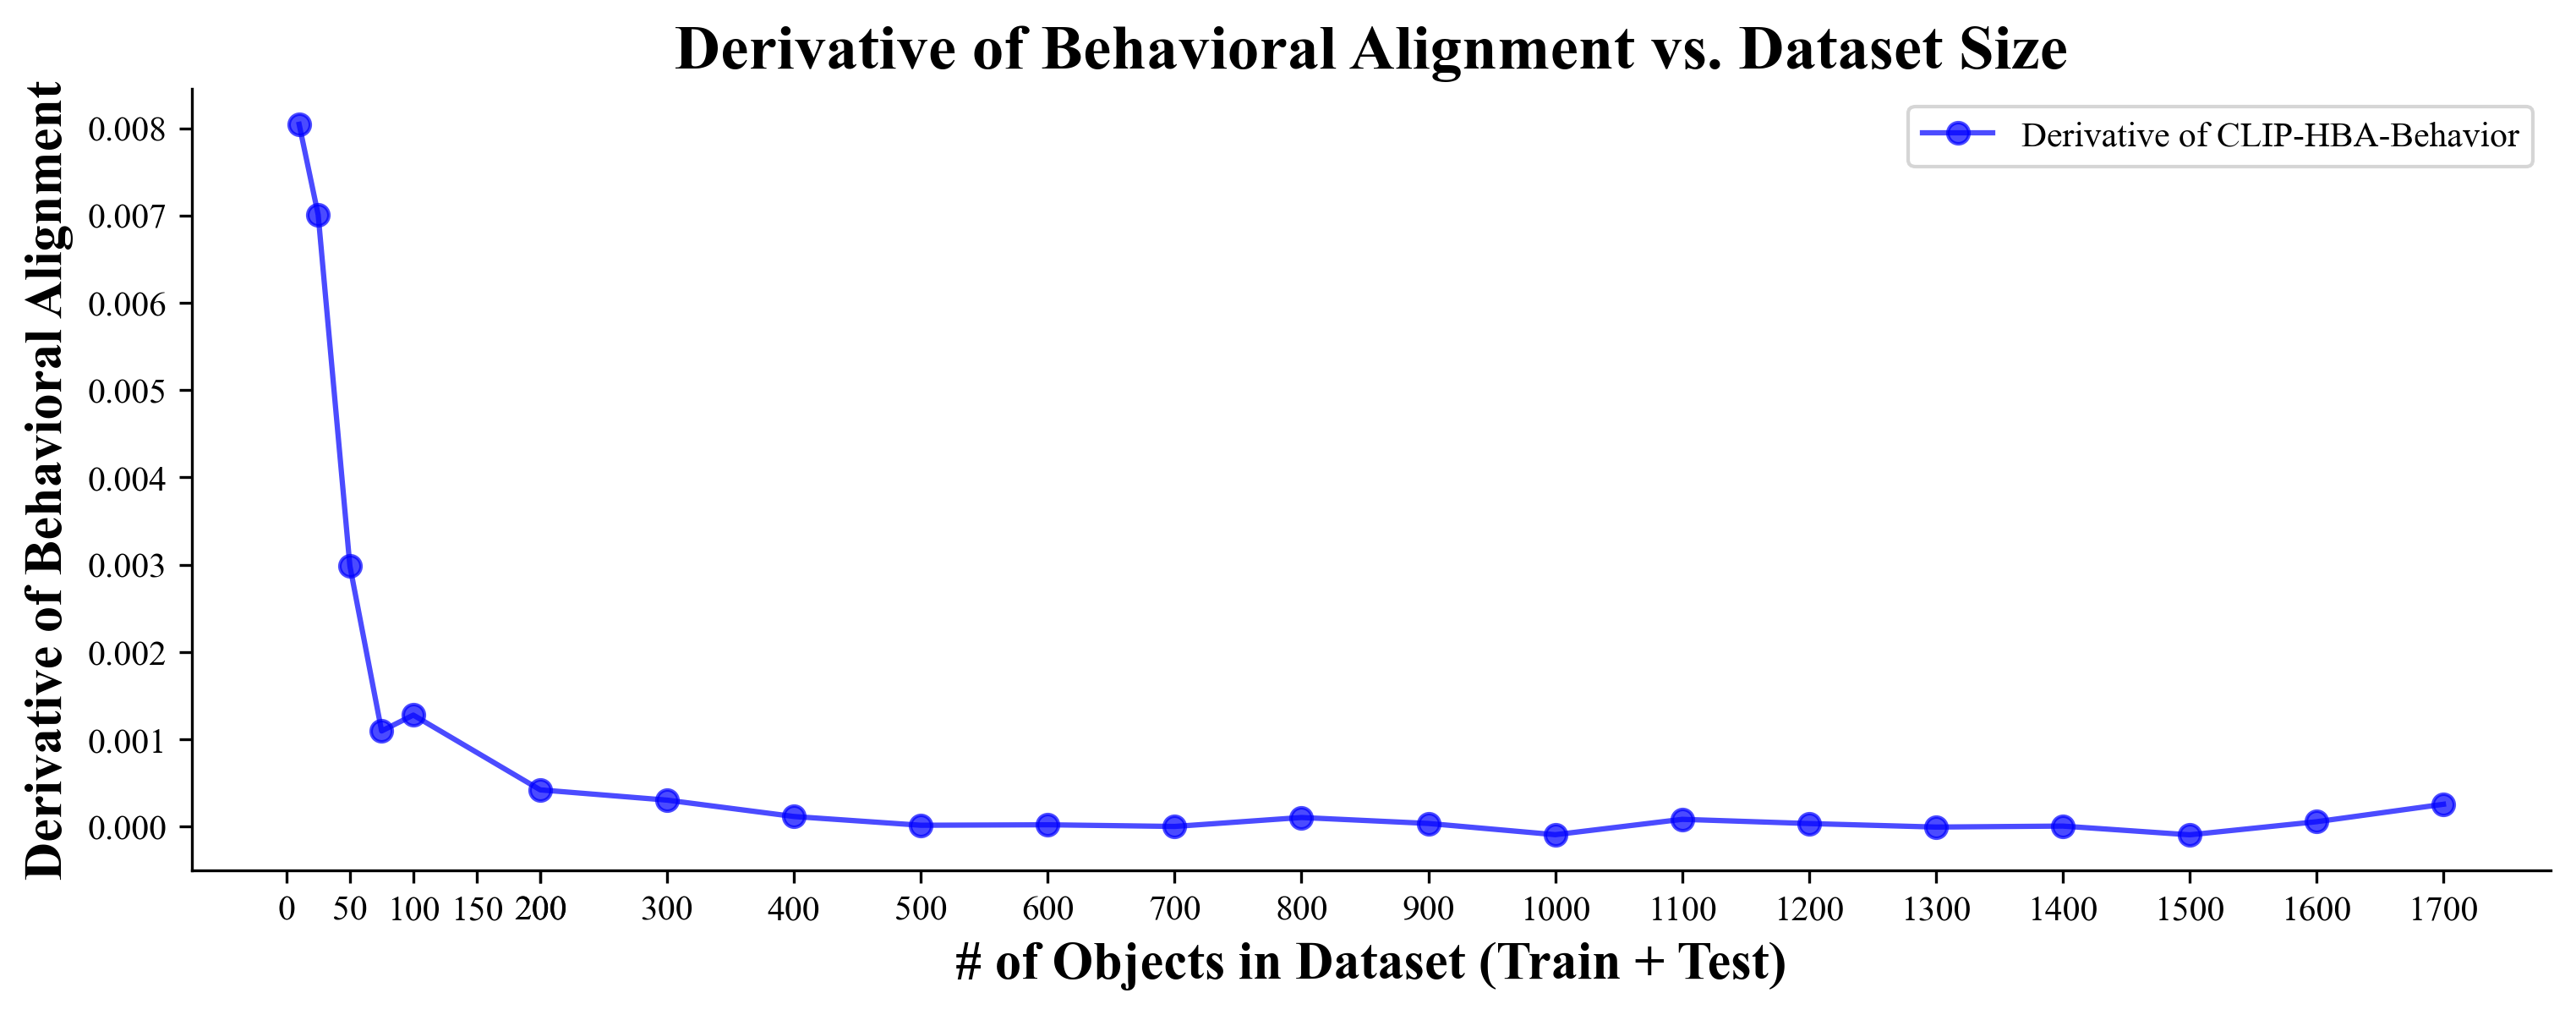

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Load the dataset
path = './cliphba_behavioral_sizes.csv'
df = pd.read_csv(path)

# Compute the derivative of the red line (spearmanr vs. train_size)
train_size = df['train_size'].values
spearmanr = df['spearmanr'].values
derivative = np.gradient(spearmanr, train_size)

# Plot the derivative
fig, ax = plt.subplots(figsize=(12, 4), dpi=300)
fig.patch.set_facecolor('none')  # Remove figure background
ax.set_facecolor('none')  # Remove axes background

ax.plot(train_size, derivative, marker='o', color='b', label='Derivative of CLIP-HBA-Behavior', alpha=0.7)

# Add labels, title, and legend
ax.set_xlabel('# of Objects in Dataset (Train + Test)', fontsize=15, fontweight='bold')
ax.set_ylabel('Derivative of Behavioral Alignment', fontsize=15, fontweight='bold')
ax.set_title('Derivative of Behavioral Alignment vs. Dataset Size', fontsize=18, fontweight='bold')
ax.legend()

# Remove top and right frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Customize grid and ticks
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)
# adjust x bin to every 25 before 100 and then every 100 after 100
# Customize x-axis ticks
ticks_before_100 = np.arange(0, 201, 50)  # Every 25 up to 100
ticks_after_100 = np.arange(200, max(train_size) + 1, 100)  # Every 100 after 100
custom_ticks = np.concatenate([ticks_before_100, ticks_after_100])
ax.set_xticks(custom_ticks)

# Display the plot
plt.savefig('behavioral_size_search_derivative.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
